In [7]:
!pip install yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 10.7 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/6 [peewee]  WARNING: The script pwiz is installed in '/home/783cfd43-2fbc-493f-8472-2132e4c86e21/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [websockets]  WARNING: The script websockets is installed in '/home/783cfd43-2fbc-493f-8472-2132e4c86e21/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 4/6 [curl_cffi]  WARNING: The script curl-cffi is installed in '/home/783cfd43-2fbc-493f-8472-2132e4c86e21/.local/bin' which is not on PATH.
  Consider add

✅ Reliance fetched
✅ Tcs fetched
✅ Infosys fetched
✅ HDFC fetched
✅ Wipro fetched
✅ ONGC fetched
✅ ITC fetched
✅ Bajaj fetched
✅ Axis fetched

Live fundamental data loaded:
      Stock   Sector    Price     EPS  PE_Ratio   ROE  Debt_to_Equity  \
0  Reliance   Energy  1388.20   59.70     23.25  0.09           36.65   
1       Tcs       IT  2392.90  136.00     17.59  0.48           10.39   
2   Infosys       IT   763.65   44.82     17.04  0.14            0.00   
3      HDFC  Finance   196.68   12.57     15.65  0.15           22.85   
4     Wipro       IT   281.00   30.24      9.29  0.00           43.80   
5      ONGC   Energy   305.85   16.26     18.81  0.00            0.51   
6       ITC     FMCG   936.05   30.48     30.71  0.18          313.41   
7     Bajaj  Finance  1272.30   84.47     15.06  0.13            0.00   
8      Axis  Finance  1194.90   61.36     19.47  0.23            6.93   

   Profit_Margin  Revenue_Growth  
0           7.64            12.5  
1          18.43          

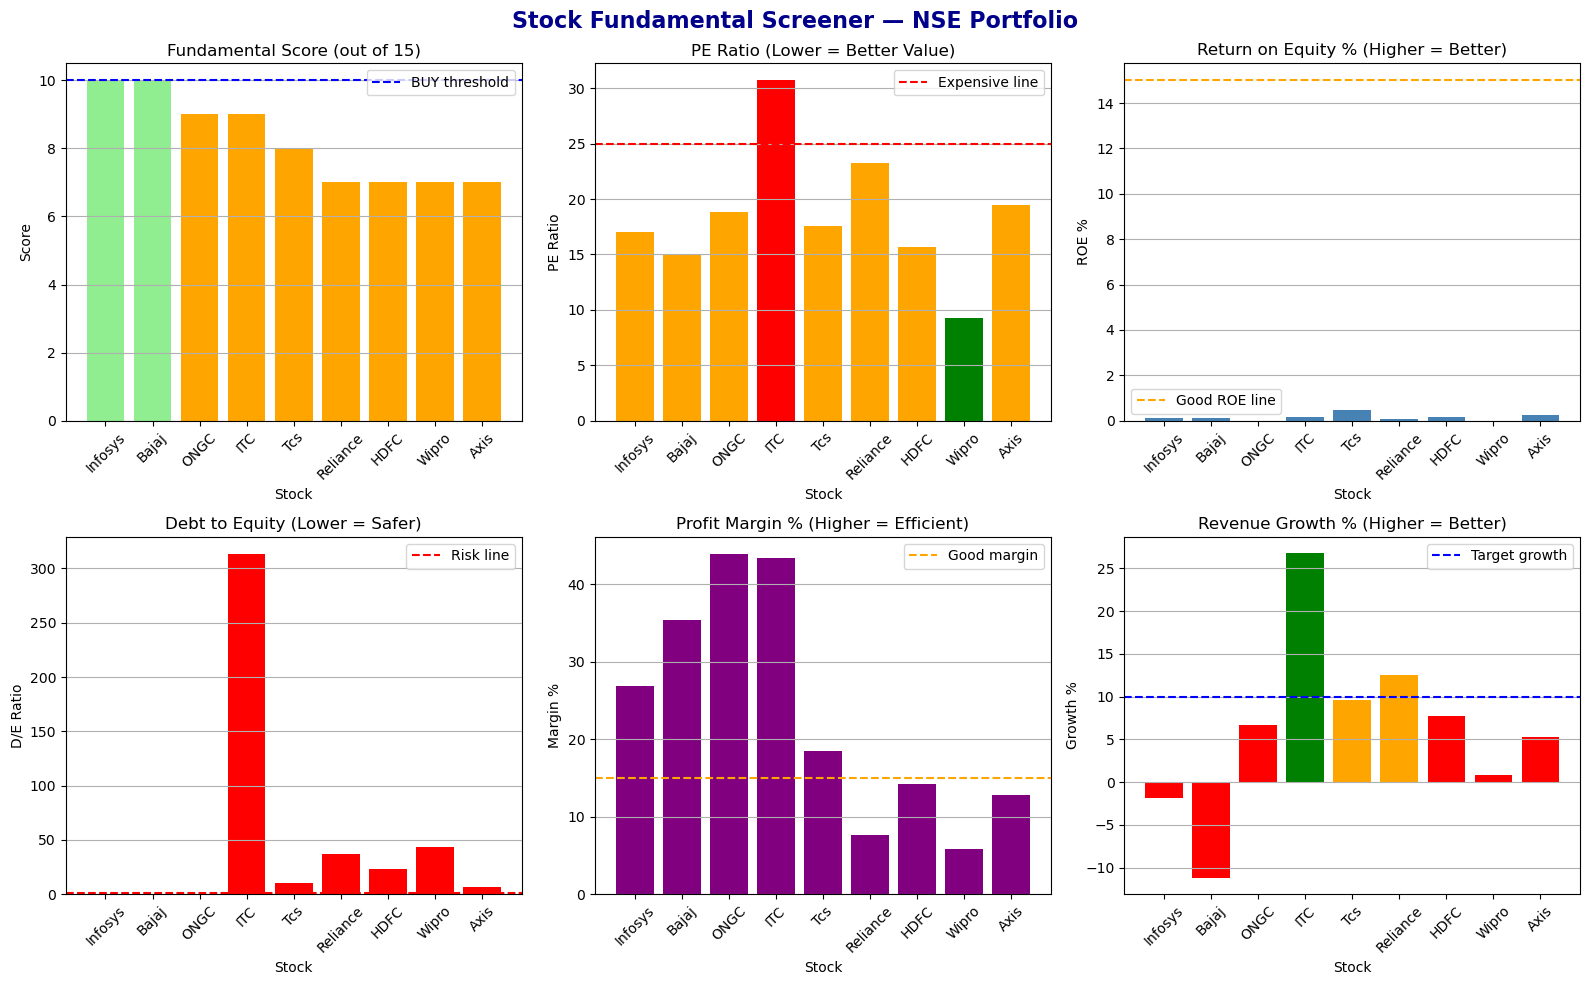

Chart saved.
     FUNDAMENTAL ANALYSIS REPORT — NSE PORTFOLIO

TOP PICKS — STRONG BUY:
  None today

BUY SIGNALS:
  📈 Infosys | Score: 10/15 | PE: 17.04
  📈 Bajaj | Score: 10/15 | PE: 15.06

AVOID — HIGH RISK:

SECTOR SUMMARY:
         PE_Ratio   ROE  Total_Score
Sector                              
Energy      21.03  0.04         8.00
FMCG        30.71  0.18         9.00
Finance     16.73  0.17         8.00
IT          14.64  0.21         8.33

FULL RANKING:
   Stock   Price  PE_Ratio  ROE  Debt_to_Equity  Total_Score Signal Risk_Level
 Infosys  763.65     17.04 0.14            0.00           10    BUY   LOW RISK
   Bajaj 1272.30     15.06 0.13            0.00           10    BUY   LOW RISK
    ONGC  305.85     18.81 0.00            0.51            9   HOLD   LOW RISK
     ITC  936.05     30.71 0.18          313.41            9   HOLD  HIGH RISK
     Tcs 2392.90     17.59 0.48           10.39            8   HOLD  HIGH RISK
Reliance 1388.20     23.25 0.09           36.65            7  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
tickers=[ 
    "RELIANCE.NS","TCS.NS","HDFCBANK.NS","WIPRO.NS","ONGC.NS","ITC.NS","BAJFINANCE.NS","AXISBANK.NS","HCLTECH.NS"
]
names=["Reliance","Tcs","Infosys","HDFC","Wipro","ONGC","ITC","Bajaj","Axis","HCL"]
sectors=["Energy","IT","IT","Finance","IT","Energy","FMCG","Finance","Finance","IT"]
records=[]
for ticker,name,sector in zip(tickers,names,sectors):
    stock=yf.Ticker(ticker)
    info=stock.info

    price=round(info.get("currentPrice",0),2)
    pe=round(info.get("trailingPE",0),2)
    eps=round((info.get("trailingEps",0)or 0),2)
    roe=round(info.get("returnOnEquity",0)or 0,2)
    de=round((info.get("debtToEquity",0)or 0),2)
    margin=round((info.get("profitMargins",0) or 0)*100,2)
    growth=round((info.get("revenueGrowth",0)or 0)*100,2)

    records.append({
        "Stock":   name,
        "Sector":  sector,
        "Price":   price,
        "EPS":     eps,
        "PE_Ratio": pe,
        "ROE":     roe,
        "Debt_to_Equity": de,
        "Profit_Margin":margin,
        "Revenue_Growth":growth})
    print(f"✅ {name} fetched")

df=pd.DataFrame(records)
print("\nLive fundamental data loaded:")
print(df)

def score_pe(pe):
   
    if pe < 15:
        return 3       
    elif pe < 25:
        return 2       
    else:
        return 1      

def score_roe(roe):
    
    if roe > 25:
        return 3       
    elif roe > 15:
        return 2      
    else:
        return 1       

def score_debt(de):
    
    if de < 0.5:
        return 3      
    elif de < 1.5:
        return 2      
    else:
        return 1       
def score_margin(margin):
    
    if margin > 20:
        return 3      
    elif margin > 10:
        return 2       
    else:
        return 1      

def score_growth(growth):
    
    if growth > 15:
        return 3       
    elif growth > 8:
        return 2      
    else:
        return 1       

# apply all scores
df["PE_Score"]     = df["PE_Ratio"].apply(score_pe)
df["ROE_Score"]    = df["ROE"].apply(score_roe)
df["Debt_Score"]   = df["Debt_to_Equity"].apply(score_debt)
df["Margin_Score"] = df["Profit_Margin"].apply(score_margin)
df["Growth_Score"] = df["Revenue_Growth"].apply(score_growth)
df["Total_Score"] = (df["PE_Score"] + df["ROE_Score"] +
                     df["Debt_Score"] + df["Margin_Score"] +
                     df["Growth_Score"])

print("\nScores calculated:")
print(df[["Stock","PE_Score","ROE_Score",
          "Debt_Score","Margin_Score",
          "Growth_Score","Total_Score"]])
def fundamental_signal(score):
    if score >= 13:
        return "STRONG BUY"
    elif score >= 10:
        return "BUY"
    elif score >= 7:
        return "HOLD"
    else:
        return "AVOID"

def risk_level(de, pe):
    if de > 2 or pe > 30:
        return "HIGH RISK"
    elif de > 1 or pe > 25:
        return "MEDIUM RISK"
    else:
        return "LOW RISK"

df["Signal"]    = df["Total_Score"].apply(fundamental_signal)
df["Risk_Level"] = df.apply(
    lambda row: risk_level(row["Debt_to_Equity"],
                           row["PE_Ratio"]), axis=1)

# sort by score — best stocks first
df = df.sort_values("Total_Score", ascending=False).reset_index(drop=True)

print("\nFundamental signals generated:")
print(df[["Stock","Total_Score","Signal","Risk_Level"]])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Stock Fundamental Screener — NSE Portfolio",
             fontsize=16, fontweight="bold", color="darkblue")

# Chart 1 — Total score bar chart
colors = ["green" if s == "STRONG BUY" else
          "lightgreen" if s == "BUY" else
          "orange" if s == "HOLD" else
          "red" for s in df["Signal"]]
axes[0,0].bar(df["Stock"], df["Total_Score"], color=colors)
axes[0,0].set_title("Fundamental Score (out of 15)")
axes[0,0].set_xlabel("Stock")
axes[0,0].set_ylabel("Score")
axes[0,0].axhline(y=10, color="blue", linestyle="--",
                   label="BUY threshold")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].legend()
axes[0,0].grid(axis="y")

# Chart 2 — PE Ratio comparison
pe_colors = ["red" if pe > 25 else
             "orange" if pe > 15 else
             "green" for pe in df["PE_Ratio"]]
axes[0,1].bar(df["Stock"], df["PE_Ratio"], color=pe_colors)
axes[0,1].set_title("PE Ratio (Lower = Better Value)")
axes[0,1].set_xlabel("Stock")
axes[0,1].set_ylabel("PE Ratio")
axes[0,1].axhline(y=25, color="red", linestyle="--",
                   label="Expensive line")
axes[0,1].tick_params(axis="x", rotation=45)
axes[0,1].legend()
axes[0,1].grid(axis="y")

# Chart 3 — ROE comparison
axes[0,2].bar(df["Stock"], df["ROE"],
              color="steelblue")
axes[0,2].set_title("Return on Equity % (Higher = Better)")
axes[0,2].set_xlabel("Stock")
axes[0,2].set_ylabel("ROE %")
axes[0,2].axhline(y=15, color="orange", linestyle="--",
                   label="Good ROE line")
axes[0,2].tick_params(axis="x", rotation=45)
axes[0,2].legend()
axes[0,2].grid(axis="y")

# Chart 4 — Debt to Equity
de_colors = ["red" if de > 2 else
             "orange" if de > 1 else
             "green" for de in df["Debt_to_Equity"]]
axes[1,0].bar(df["Stock"], df["Debt_to_Equity"], color=de_colors)
axes[1,0].set_title("Debt to Equity (Lower = Safer)")
axes[1,0].set_xlabel("Stock")
axes[1,0].set_ylabel("D/E Ratio")
axes[1,0].axhline(y=1, color="red", linestyle="--",
                   label="Risk line")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].legend()
axes[1,0].grid(axis="y")

# Chart 5 — Profit margin
axes[1,1].bar(df["Stock"], df["Profit_Margin"],
              color="purple")
axes[1,1].set_title("Profit Margin % (Higher = Efficient)")
axes[1,1].set_xlabel("Stock")
axes[1,1].set_ylabel("Margin %")
axes[1,1].axhline(y=15, color="orange", linestyle="--",
                   label="Good margin")
axes[1,1].tick_params(axis="x", rotation=45)
axes[1,1].legend()
axes[1,1].grid(axis="y")

# Chart 6 — Revenue growth
growth_colors = ["green" if g > 15 else
                 "orange" if g > 8 else
                 "red" for g in df["Revenue_Growth"]]
axes[1,2].bar(df["Stock"], df["Revenue_Growth"],
              color=growth_colors)
axes[1,2].set_title("Revenue Growth % (Higher = Better)")
axes[1,2].set_xlabel("Stock")
axes[1,2].set_ylabel("Growth %")
axes[1,2].axhline(y=10, color="blue", linestyle="--",
                   label="Target growth")
axes[1,2].tick_params(axis="x", rotation=45)
axes[1,2].legend()
axes[1,2].grid(axis="y")

plt.tight_layout()
plt.savefig("fundamental_screener.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

print("=" * 60)
print("     FUNDAMENTAL ANALYSIS REPORT — NSE PORTFOLIO")
print("=" * 60)

print("\nTOP PICKS — STRONG BUY:")
strong = df[df["Signal"] == "STRONG BUY"]
if len(strong) > 0:
    for _, row in strong.iterrows():
        print(f"  ✅ {row['Stock']} | Score: {row['Total_Score']}/15 | PE: {row['PE_Ratio']} | ROE: {row['ROE']}%")
else:
    print("  None today")

print("\nBUY SIGNALS:")
buy = df[df["Signal"] == "BUY"]
for _, row in buy.iterrows():
    print(f"  📈 {row['Stock']} | Score: {row['Total_Score']}/15 | PE: {row['PE_Ratio']}")

print("\nAVOID — HIGH RISK:")
avoid = df[df["Signal"] == "AVOID"]
for _, row in avoid.iterrows():
    print(f"  ⚠️  {row['Stock']} | Score: {row['Total_Score']}/15 | D/E: {row['Debt_to_Equity']}")

print("\nSECTOR SUMMARY:")
sector_avg = df.groupby("Sector")[["PE_Ratio",
                                    "ROE",
                                    "Total_Score"]].mean().round(2)
print(sector_avg)

print("\nFULL RANKING:")
print(df[["Stock","Price","PE_Ratio","ROE",
          "Debt_to_Equity","Total_Score",
          "Signal","Risk_Level"]].to_string(index=False))
print("=" * 60)
